In [51]:
import torch
from torch.distributed.algorithms.ddp_comm_hooks.powerSGD_hook import batched_powerSGD_hook
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Create synthetic classification dataset

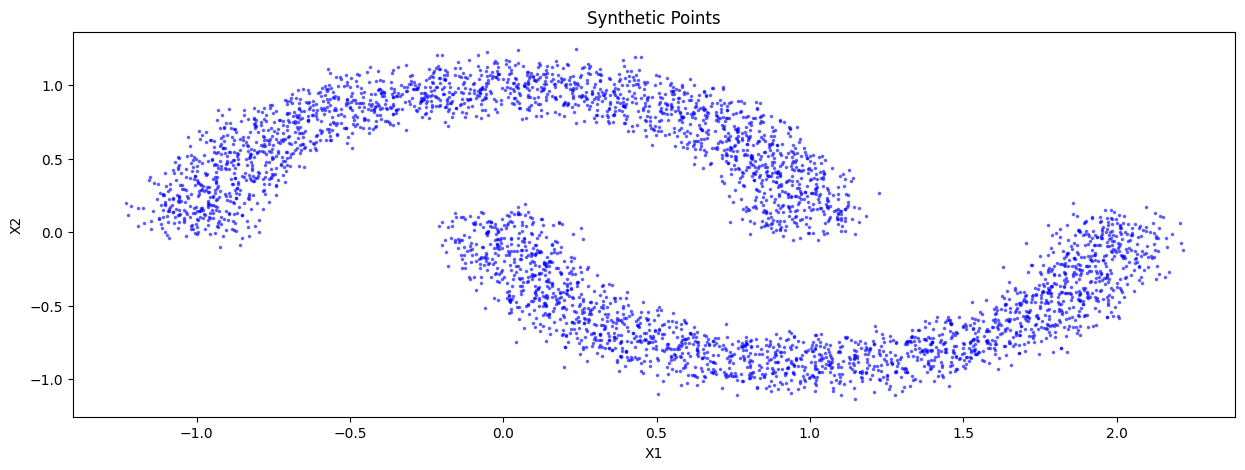

In [52]:
def generate_moon(n_samples=500, radius=1.0, width=0.3, distance=0.1, noise=0.05, flip=False):
    angles = np.linspace(0, np.pi, n_samples)
    r = radius + width * (np.random.rand(n_samples) - 0.5)
    x = r * np.cos(angles)
    y = r * np.sin(angles)

    if flip:
        x = -x + radius  # flip and shift right
        y = -y + distance  # shift down

    x += np.random.normal(0, noise, n_samples)
    y += np.random.normal(0, noise, n_samples)

    x = torch.from_numpy(x).float()
    y = torch.from_numpy(y).float()
    return torch.column_stack([x,y])






def generate_x_points(n_samples=1000):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    # Generate both moons
    moon1 = generate_moon(n_samples)
    moon2= generate_moon(n_samples,flip=True)
    points = torch.concatenate([moon1, moon2], dim=0).numpy()
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points()
point_bunch2 = generate_x_points()
data = np.concatenate((point_bunch,point_bunch2),axis=0).astype(np.float32)
# Visualize points
visualize_points(data)

# Define True Target Probability Distribution

In [53]:
# define 1st order probability distribution

def generate_y_probs(points):
    # Parameters for moons
    r = 1.0
    center0 = torch.tensor(np.array([0, 0],dtype=float))       # First moon
    center1 = torch.tensor(np.array([1, 0.5], dtype=float))     # Second moon (flipped and shifted)

    # Convert to polar coordinates relative to each moon
    rel0 = points - center0
    rel1 = points - center1

    theta0 = torch.arctan2(rel0[:,1], rel0[:,0])
    theta1 = torch.arctan2(-rel1[:,1], rel1[:,0])  # flipped second moon

    r0 = torch.linalg.norm(rel0, dim=1)
    r1 = torch.linalg.norm(rel1, dim=1)

    # Mask angles: first moon lives in [0, pi], second in [0, pi] after flip
    arc0 = (theta0 >= 0) & (theta0 <= np.pi)
    arc1 = (theta1 >= 0) & (theta1 <= np.pi)

    # Score proximity to moon arcs (lower deviation → higher probability)
    score0 = arc0 * (1 - torch.abs(r0 - r))  # closer to radius 1
    score1 = arc1 * (1 - torch.abs(r1 - r))

    # Decision value
    z = score0 - score1

    # Sigmoid probability
    probs = 1 / (1 + torch.exp(-z))  # sharper boundary with higher factor
    y_probs = torch.stack([1-probs, probs], dim=-1)
    return y_probs.clip(1e-8,(9999999)/1e7)

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(data))
y_probs

tensor([[0.3809, 0.6191],
        [0.3637, 0.6363],
        [0.4016, 0.5984],
        ...,
        [0.7129, 0.2871],
        [0.7226, 0.2774],
        [0.7114, 0.2886]], dtype=torch.float64)

# Define Ensemble

In [54]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier, MC_Classifier
ENSEMBLE_MEMBER_COUNT = 10
base_ensemble = [MLP_Classifier(input_shape=2,n_classes=2,n_layers=2,num_neurons=10,dropout_prob=0,batch_norm=False,) for  _ in range(ENSEMBLE_MEMBER_COUNT)]
ensemble_model = Ensemble_Classifier(base_ensemble,n_models=10)
ensemble_model.fit(data,y_labels)
ensemble_model.save("models/Ensemble_Two_Moon/")
ensemble_model.load("models/Ensemble_Two_Moon/")

Using MPS Device for training
Using fast routine
Finished Epoch 0 from 50 with 7.066758155822754
Finished Epoch 1 from 50 with 6.79854679107666
Finished Epoch 2 from 50 with 6.571804523468018
Finished Epoch 3 from 50 with 6.303172588348389
Finished Epoch 4 from 50 with 5.969701766967773
Finished Epoch 5 from 50 with 5.556452751159668
Finished Epoch 6 from 50 with 5.081511974334717
Finished Epoch 7 from 50 with 4.57158899307251
Finished Epoch 8 from 50 with 4.062636375427246
Finished Epoch 9 from 50 with 3.5846104621887207
Finished Epoch 10 from 50 with 3.155627965927124
Finished Epoch 11 from 50 with 2.7848763465881348
Finished Epoch 12 from 50 with 2.4725582599639893
Finished Epoch 13 from 50 with 2.2122180461883545
Finished Epoch 14 from 50 with 1.9942052364349365
Finished Epoch 15 from 50 with 1.8116028308868408
Finished Epoch 16 from 50 with 1.6572177410125732
Finished Epoch 17 from 50 with 1.5247355699539185
Finished Epoch 18 from 50 with 1.4087902307510376
Finished Epoch 19 from 

In [55]:
def ensemble_probs(points):
    probs,_ = ensemble_model.predict(points,raw_output=True)
    return probs
y_probs_ensemble_points = ensemble_probs(data)
y_pred_ensemble_points = y_probs_ensemble_points.mean(dim=1).argmax(dim=1)

In [56]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=1)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=1)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)

# Visualize Data

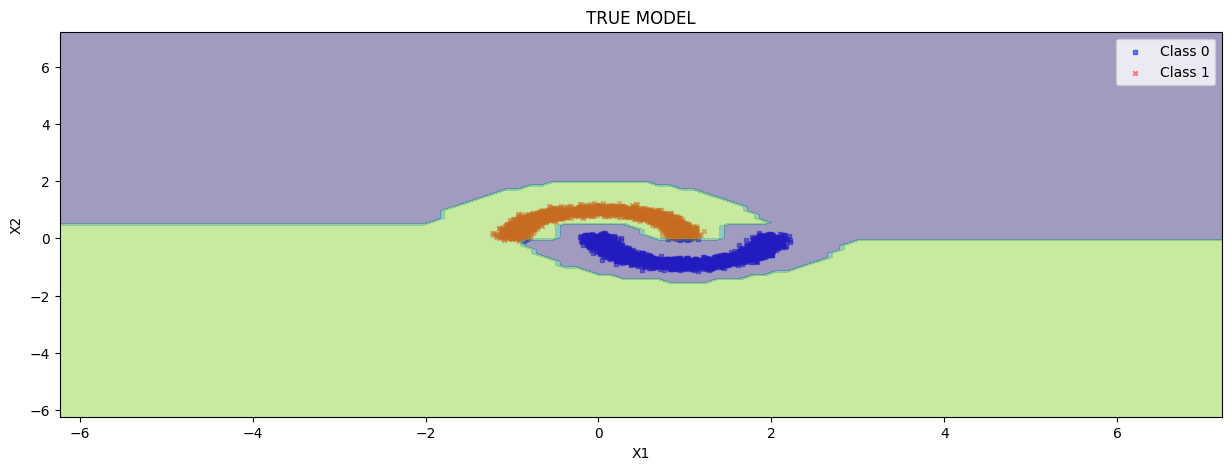

In [57]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(data,y_labels)

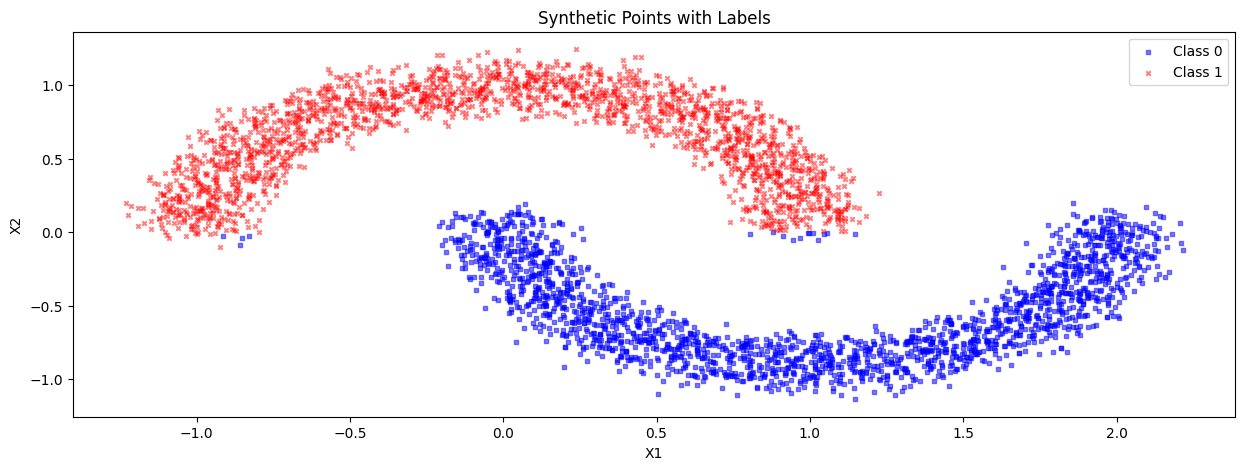

In [58]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(data, y_labels)

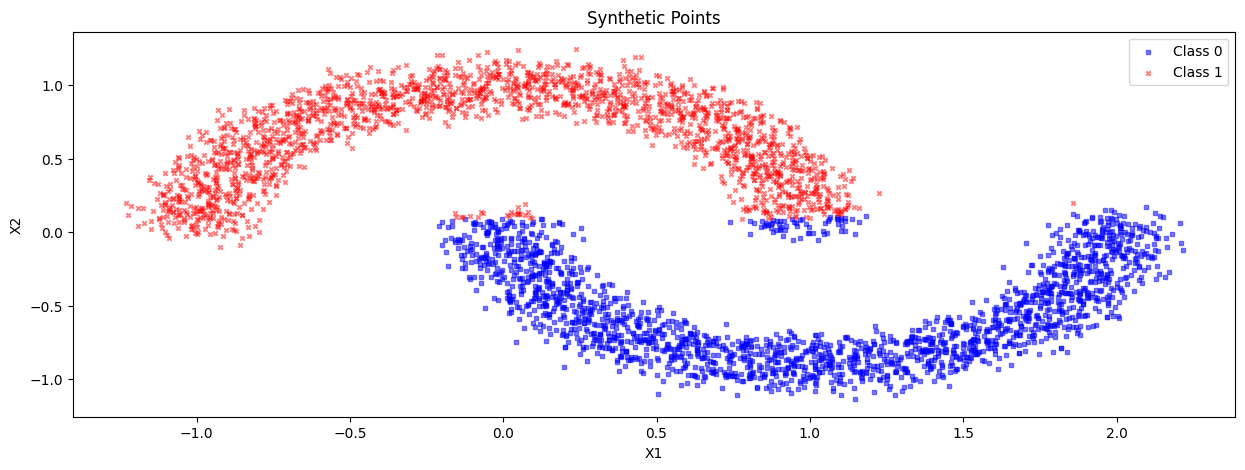

In [59]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(data, y_pred_ensemble_points)


# Visualize TU/AU/EU

torch.Size([10000, 10, 2])
tensor(8.9778e-07, grad_fn=<MinBackward1>) tensor(1., grad_fn=<MaxBackward1>)


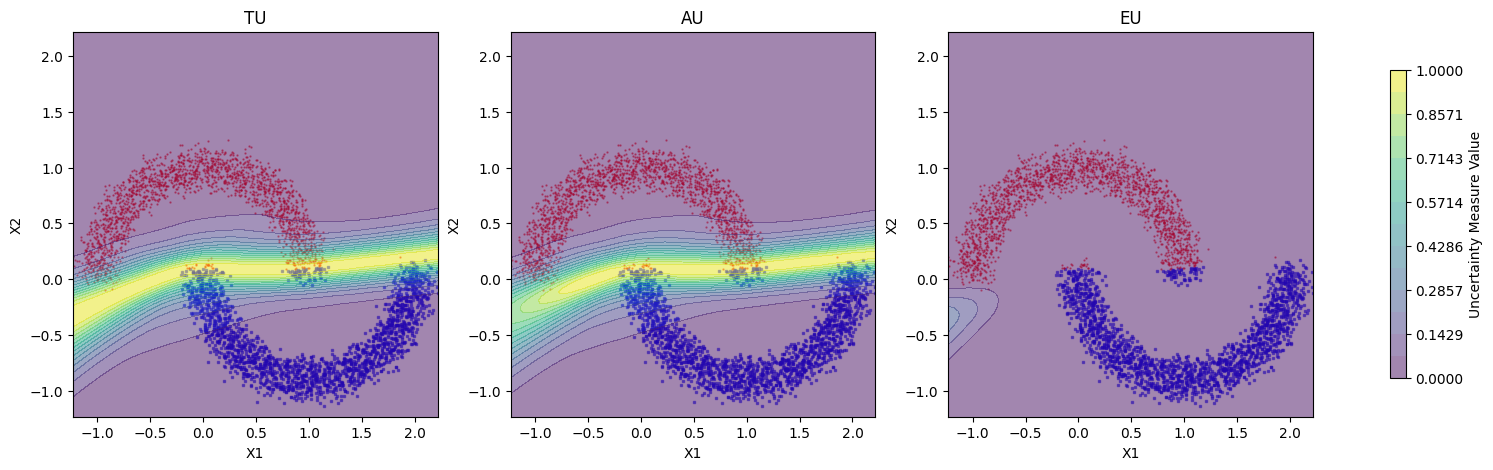

In [60]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points))
    print(y_probs_ensemble.shape)
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, values, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='.', s=2, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, values.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(data,y_pred_ensemble_points)

# Visualize AU & EU Aggregations

In [61]:
def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples.reshape(-1,2)).requires_grad_(True)

tensor(1.9551e-07, grad_fn=<MinBackward1>) tensor(0.4256, grad_fn=<MaxBackward1>)


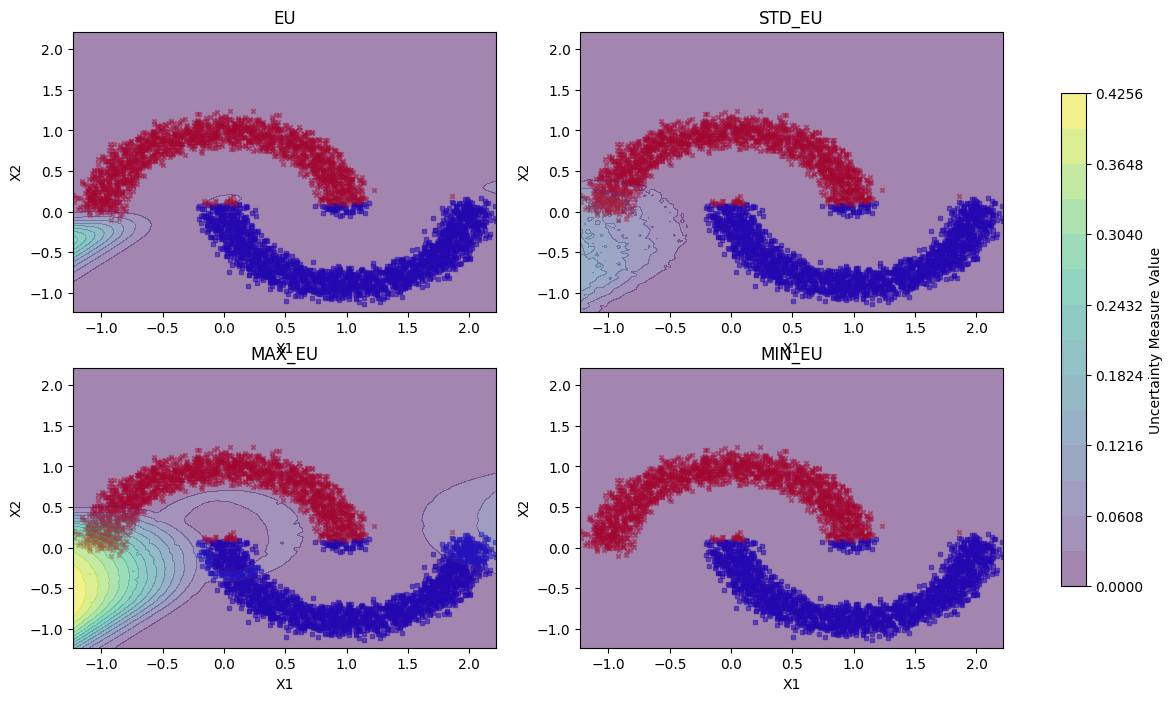

In [62]:
# visualize how std of eu looks like aroung the points
def visualize_eu_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)

    std_eu_ball = torch.std(eu_delta_ball,dim=0)
    max_eu_ball = torch.max(eu_delta_ball,dim=0)[0]
    min_eu_ball = torch.min(eu_delta_ball,dim=0)[0]
    mean_eu_ball = torch.mean(eu_delta_ball,dim=0)


    # Shared value range
    all_vals = torch.concatenate([std_eu_ball, epistemic_uncertainty, max_eu_ball, min_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [epistemic_uncertainty, std_eu_ball, max_eu_ball, min_eu_ball], ["EU","STD_EU", "MAX_EU", "MIN_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_eu_std_points(data,y_pred_ensemble_points,delta=0.5,n_points=100)

tensor(1.3916e-06, grad_fn=<MinBackward1>) tensor(0.9977, grad_fn=<MaxBackward1>)


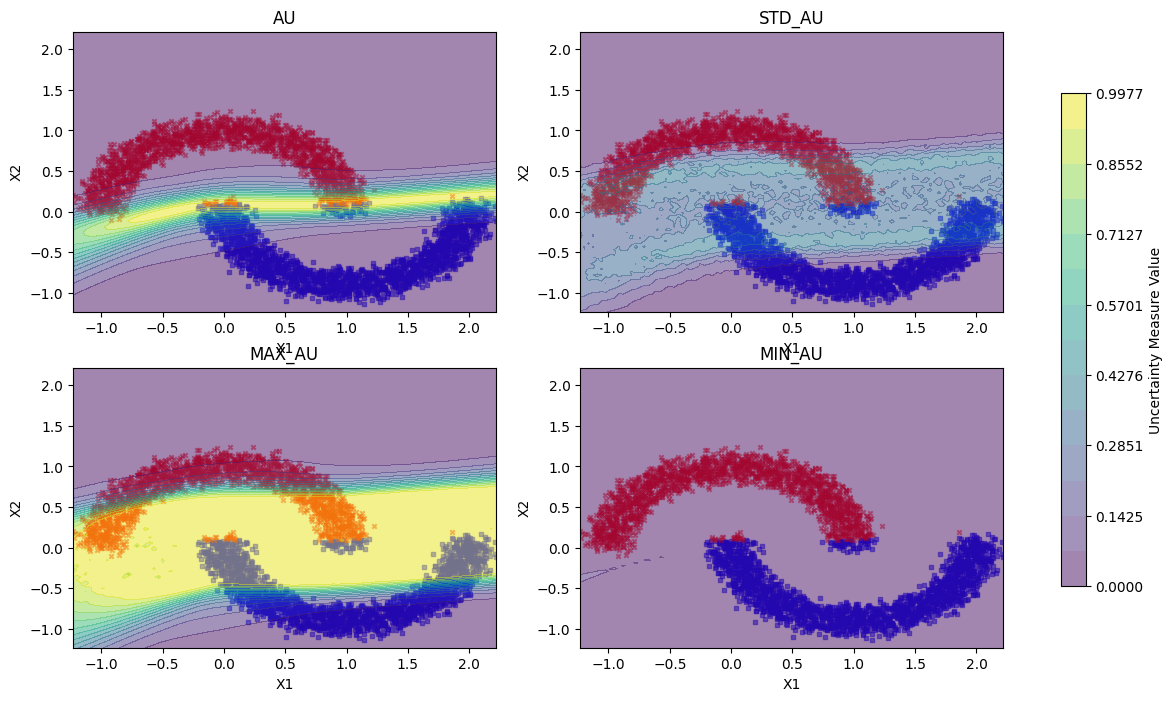

In [63]:
# visualize how std of eu looks like aroung the points
def visualize_eu_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)



    std_au_ball = torch.std(au_delta_ball,dim=0)
    max_au_ball = torch.max(au_delta_ball,dim=0)[0]
    min_au_ball = torch.min(au_delta_ball,dim=0)[0]


    # Shared value range
    all_vals = torch.concatenate([std_au_ball, aleatoric_uncertainty, max_au_ball, min_au_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [aleatoric_uncertainty, std_au_ball, max_au_ball, min_au_ball], ["AU","STD_AU", "MAX_AU", "MIN_AU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_eu_std_points(data,y_pred_ensemble_points,delta=0.5,n_points=100)

# CF construction

In [64]:
MAX_STEPS = 1000
UNCERTAINTY_STEP_INCREASE = 1e-2
DESIRED_VALIDITY = 0.9
#point_of_interest = torch.tensor(np.array([-1,0]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest = torch.tensor(np.array([2, -0.5]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

## Validity
We now work in the scenario of creating a valid counter factual for our point x

In [65]:
def validity_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Get the probs in the start
    probs = ensemble_probs(counter_factual).mean(dim=0)
    target_probs = probs[0,desired_class]
    # Optimization Iteration
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs = ensemble_probs(counter_factual).mean(dim=0)
        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = -target_probs
        #print(target_probs)
        # Backpropagate
        loss.backward()
        #print(counter_factual)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_valid, cf_steps_valid = validity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

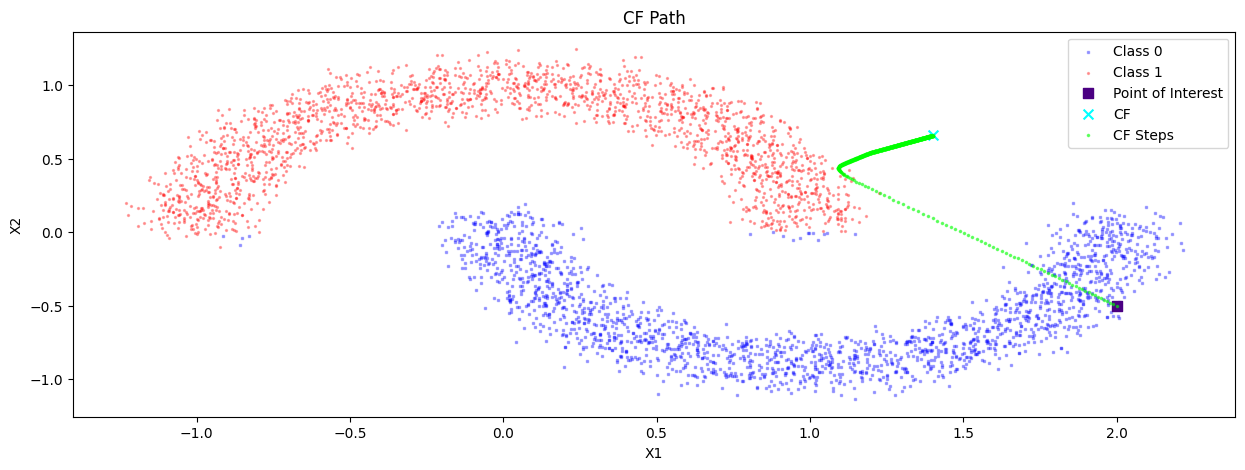

In [66]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.3, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=2, alpha=0.3, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=50, alpha=1, color='indigo', label="Point of Interest")

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, color='aqua', label="CF")

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='lime', label="CF Steps")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")

    plt.legend()
visualize_cf_and_steps(cf_valid, cf_steps_valid, data, y_labels)

## Plausability

In [67]:
def plausability_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        # Calculate the loss
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        lam = 0.7
        loss = (-target_probs)  + lam*eu

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_plausable, cf_steps_plausable = plausability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

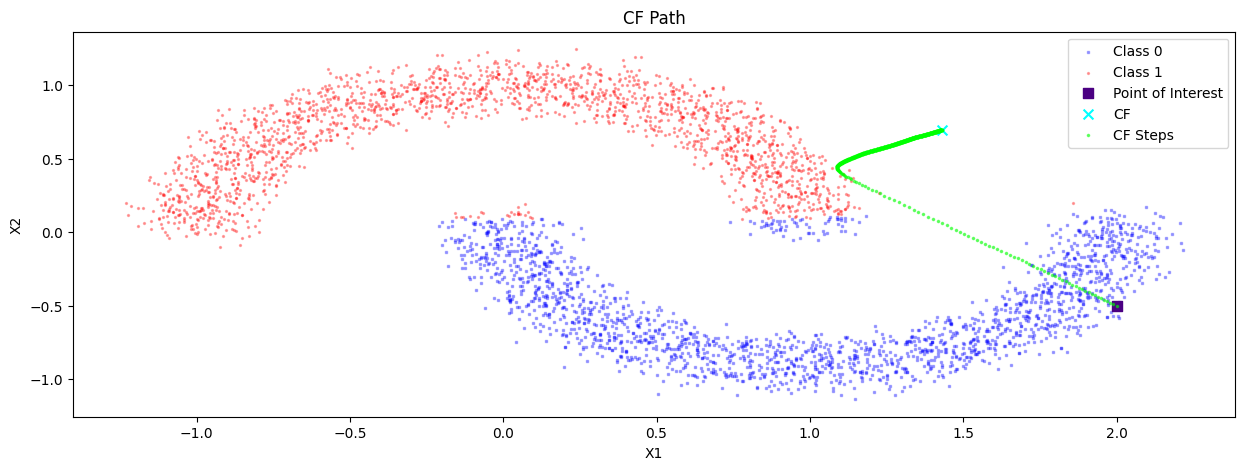

In [68]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, data, y_pred_ensemble_points)

In [69]:
cf_plausable, cf_valid

(tensor([[1.4305, 0.6960]]), tensor([[1.4013, 0.6572]]))

In [70]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(cf_valid))

(tensor([0.0012], grad_fn=<ClampBackward1>),
 tensor([0.0014], grad_fn=<ClampBackward1>))

## Discrimitiveness

In [71]:
def discriminiative_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam=0.7 if target_probs > 0.5 else 0
        loss = (-target_probs) + lam*au

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual,au, t)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

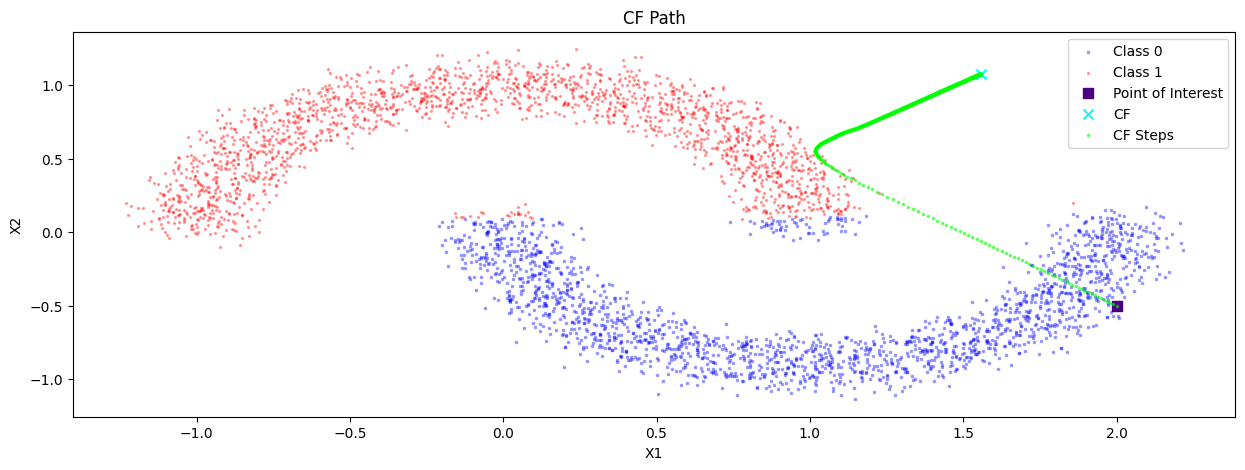

In [72]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, data, y_pred_ensemble_points)


In [73]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[1.5578, 1.0781]]),
 tensor([[1.4305, 0.6960]]),
 tensor([[1.4013, 0.6572]]))

In [74]:
aleatoric_uncertainty_ensemble(ensemble_probs(cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_discriminiative))


(tensor([0.0284], grad_fn=<MeanBackward1>),
 tensor([0.0337], grad_fn=<MeanBackward1>),
 tensor([0.0068], grad_fn=<MeanBackward1>))

## Stability

In [75]:
def stable_procedure_baseline(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam = 0.2
        loss = (-target_probs_delta_ball.mean())
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0,keepdims=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable_baseline, cf_steps_stable_baseline = stable_procedure_baseline(point_of_interest,desired_validity=DESIRED_VALIDITY)


In [76]:
def stable_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam = 0.2
        loss = (1-lam)*(-target_probs_delta_ball.mean()) + lam*au_delta_ball.mean()
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0,keepdims=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable, cf_steps_stable = stable_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

In [77]:
def stable_procedure_tu_start_ball(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    au_delta_ball_start = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    eu_delta_ball_start = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        lam = 0.1
        loss =  -target_probs_delta_ball.mean() + lam*( (tu_delta_ball.mean() - tu_delta_ball_start.mean())**2 + (tu_delta_ball.std() -tu_delta_ball_start.std())**2 )
        #loss =  -((1-lam)*target_probs_delta_ball.mean()) + lam*( (au_delta_ball.mean() - au_delta_ball_start.mean())**2 + (au_delta_ball.std() -au_delta_ball_start.std())**2 )
        #loss =  -((1-lam)*target_probs_delta_ball.mean()) + lam*( (eu_delta_ball.mean() - eu_delta_ball_start.mean())**2 + (eu_delta_ball.std() -eu_delta_ball_start.std())**2 )




        # Backpropagate
        loss.backward()
        #lam = 0.9
        counter_factual.grad = delta_ball.grad.mean(dim=0,keepdims=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable_start_ball, cf_steps_stable_start_ball = stable_procedure_tu_start_ball(point_of_interest, desired_validity=DESIRED_VALIDITY, delta=0.2)

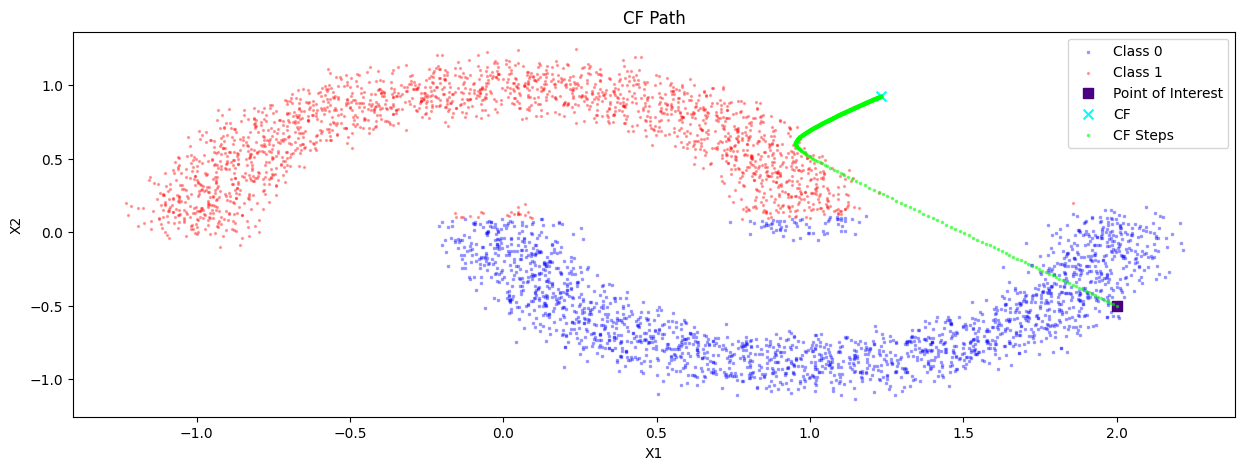

In [78]:
visualize_cf_and_steps(cf_stable_start_ball,cf_steps_stable_start_ball, data, y_pred_ensemble_points)

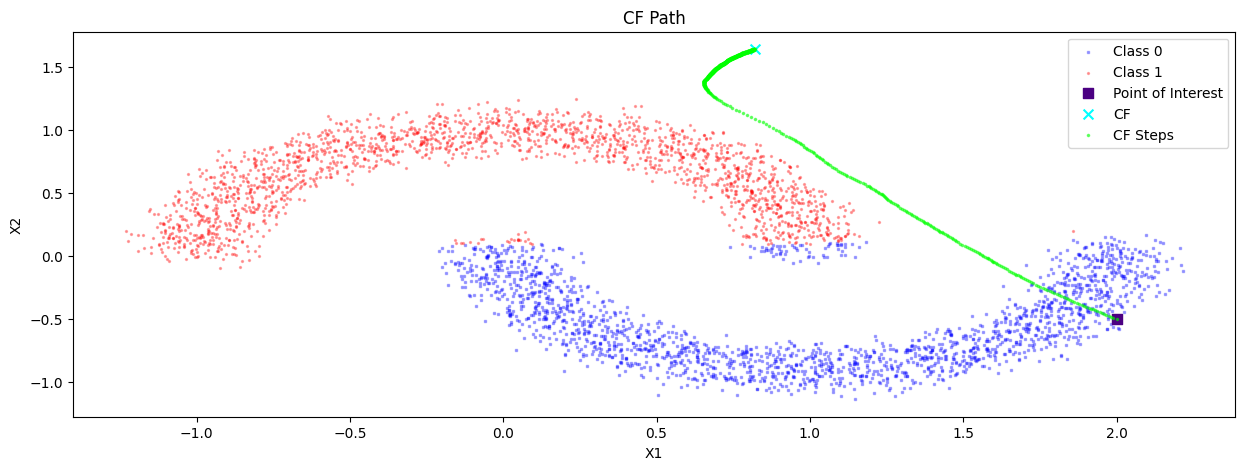

In [79]:
visualize_cf_and_steps(cf_stable_baseline,cf_steps_stable_baseline, data, y_pred_ensemble_points)


In [80]:
delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=0.4, n_points=10)
cf_points_stable = []
cf_points_stable_2 = []
cf_points_stable_3 = []
for point in delta_point_of_interest:
    cf_point, cf_steps_point = stable_procedure(point.view(-1,2), desired_validity=0.9, delta=0.2, n_points=10)
    cf_point2, _ = stable_procedure_tu_start_ball(point.view(-1, 2), delta=0.2, n_points=10)
    cf_point3,_ = stable_procedure_baseline(point.view(-1,2), delta=0.2, n_points=10)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_stable.append(cf_point)
    cf_points_stable_2.append(cf_point2)
    cf_points_stable_3.append(cf_point3)

# compare with validitiy procedure
cf_points_not_stable =[]
for point in delta_point_of_interest:
    cf_point, cf_steps_point = validity_procedure(point.view(-1,2), desired_validity=0.9)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_not_stable.append(cf_point)


# compute the mean l2 distance for stable and not stable
l2_distances_stable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_stable
    for p2 in cf_points_stable
    if (p1 != p2).all()
]
l2_distances_stable_2 = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_stable_2
    for p2 in cf_points_stable_2
    if (p1 != p2).all()
]
l2_distances_stable_3 = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_stable_3
    for p2 in cf_points_stable_3
    if (p1 != p2).all()
]
l2_distances_unstable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_not_stable
    for p2 in cf_points_not_stable
    if (p1 != p2).all()
]

print("Mean L2-Distance of Stable Procedure BALL AU: ", np.mean(l2_distances_stable), " +/- ",  np.std(l2_distances_stable))
print("Mean L2-Distance of Stable Procedure BALL TU REGARDING START: ", np.mean(l2_distances_stable_2), " +/- ",  np.std(l2_distances_stable_2))
print("Mean L2-Distance of Stable Procedure BASELINE: ", np.mean(l2_distances_stable_3), " +/- ",  np.std(l2_distances_stable_3))
print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

Mean L2-Distance of Stable Procedure BALL AU:  1.982443582225177  +/-  1.4772458298073556
Mean L2-Distance of Stable Procedure BALL TU REGARDING START:  0.14347047303906746  +/-  0.064279183827614
Mean L2-Distance of Stable Procedure BASELINE:  0.11166592605360266  +/-  0.06996947840934951
Mean L2-Distance of Unstable Procedure:  0.10837802635020731  +/-  0.08290130201562494


In [81]:
# def get_knn_points(point,k=5):
#     knn = NearestNeighbors(n_neighbors=k,algorithm="brute")
#     knn.fit(data)
#     distances, indices = knn.kneighbors(point.detach().numpy())
#     return torch.tensor(data[indices[0]]).requires_grad_(True)
#
# delta_point_of_interest = get_knn_points(point_of_interest, k=5)
# cf_points_stable = []
# cf_points_stable_2 = []
# cf_points_stable_3 = []
# for point in delta_point_of_interest:
#     cf_point, cf_steps_point = stable_procedure(point.view(-1,2), desired_validity=0.9, delta=0.2, n_points=10)
#     cf_point2, _ = stable_procedure_tu_start_ball(point.view(-1, 2), delta=0.2, n_points=10)
#     cf_point3,_ = stable_procedure_baseline(point.view(-1,2), delta=0.2, n_points=10)
#     #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
#     cf_points_stable.append(cf_point)
#     cf_points_stable_2.append(cf_point2)
#     cf_points_stable_3.append(cf_point3)
#
# # compare with validitiy procedure
# cf_points_not_stable =[]
# for point in delta_point_of_interest:
#     cf_point, cf_steps_point = validity_procedure(point.view(-1,2), desired_validity=0.9)
#     #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
#     cf_points_not_stable.append(cf_point)
#
#
# # compute the mean l2 distance for stable and not stable
# l2_distances_stable = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_stable
#     for p2 in cf_points_stable
#     if (p1 != p2).all()
# ]
# l2_distances_stable_2 = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_stable_2
#     for p2 in cf_points_stable_2
#     if (p1 != p2).all()
# ]
# l2_distances_stable_3 = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_stable_3
#     for p2 in cf_points_stable_3
#     if (p1 != p2).all()
# ]
# l2_distances_unstable = [
#     torch.norm(p1 - p2, p=2).item()
#     for p1 in cf_points_not_stable
#     for p2 in cf_points_not_stable
#     if (p1 != p2).all()
# ]
#
# print("Mean L2-Distance of Stable Procedure BALL AU: ", np.mean(l2_distances_stable), " +/- ",  np.std(l2_distances_stable))
# print("Mean L2-Distance of Stable Procedure BALL TU REGARDING START: ", np.mean(l2_distances_stable_2), " +/- ",  np.std(l2_distances_stable_2))
# print("Mean L2-Distance of Stable Procedure BASELINE: ", np.mean(l2_distances_stable_3), " +/- ",  np.std(l2_distances_stable_3))
# print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

## Robustness

In [82]:
def robust_procedure(point_to_explain, desired_validity=0.8, delta=0.2, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]

        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        std_eu_ball = torch.std(
            eu_delta_ball
        )
        mean_eu_ball = torch.mean(
            eu_delta_ball
        )


        # Calculate the loss
        lam1 = 0.7
        lam2 = 0.7 if target_probs > 0.5 else 0
        loss = -(target_probs_delta_ball.mean()) + lam1*(eu_delta_ball.max()) + lam2*(au_delta_ball.max())

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0).view(-1,2)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_robust, cf_steps_robust = robust_procedure(point_of_interest,delta=0.5,n_points=10)

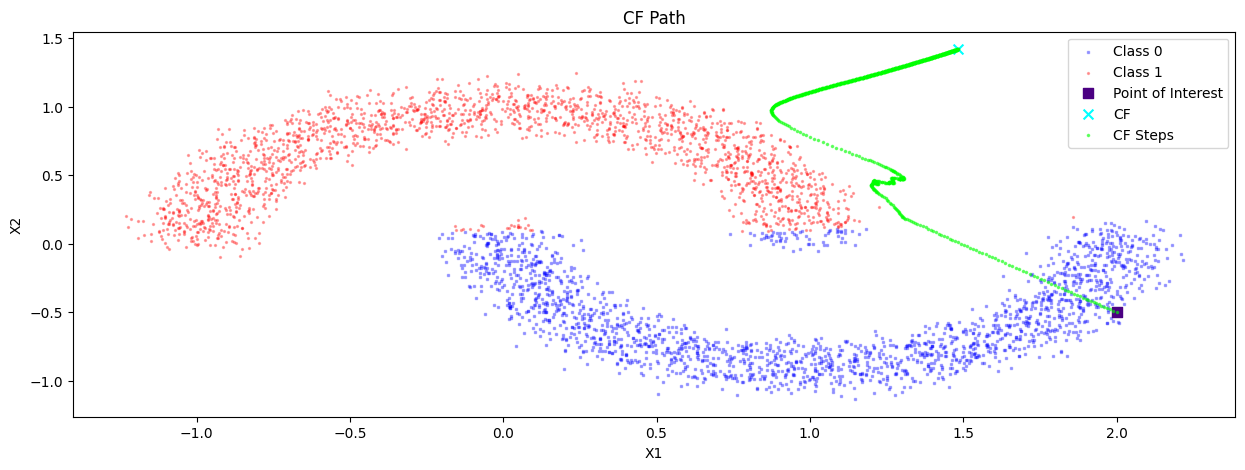

In [83]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, data, y_pred_ensemble_points)

In [84]:
cf_robust, cf_plausable

(tensor([[1.4826, 1.4187]]), tensor([[1.4305, 0.6960]]))

In [85]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable))

(tensor([0.0002], grad_fn=<ClampBackward1>),
 tensor([0.0012], grad_fn=<ClampBackward1>))

In [86]:

res_mean = []
res_std = []
for _ in range(10):
    delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_robust = []
    for point in delta_cf_robust:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_robust.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_plausable = []
    for point in delta_cf_plausable:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_plausable.append(
            epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
        )

    print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
    print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

    res_mean.append([np.mean(epistemic_cf_robust), np.mean(epistemic_cf_plausable)])
    res_std.append([np.std(epistemic_cf_robust), np.std(epistemic_cf_plausable)])

np.mean(res_mean,axis=0), np.std(res_mean,axis=0), np.mean(res_std,axis=0), np.std(res_std,axis=0)

Std Epistemic Uncertainty of Robust Procedure:  0.00016192648  +/-  8.210882e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.001436886  +/-  0.0007470155
Std Epistemic Uncertainty of Robust Procedure:  0.00017569256  +/-  9.048194e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.0015870641  +/-  0.0007564109
Std Epistemic Uncertainty of Robust Procedure:  0.00016506104  +/-  8.063892e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.0014813644  +/-  0.0007650017
Std Epistemic Uncertainty of Robust Procedure:  0.00017022926  +/-  8.596882e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.0015030659  +/-  0.00077241444
Std Epistemic Uncertainty of Robust Procedure:  0.0001767921  +/-  8.555003e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.0013840063  +/-  0.00073185796
Std Epistemic Uncertainty of Robust Procedure:  0.0001620185  +/-  8.864084e-05
Std Epistemic Uncertainty of Plausable Procedure:  0.0015667663  +/-  0.00079345785
Std Epistemic Un

(array([0.00016935, 0.0015004 ], dtype=float32),
 array([4.802844e-06, 6.750314e-05], dtype=float32),
 array([8.627509e-05, 7.564409e-04], dtype=float32),
 array([3.0206561e-06, 1.7393551e-05], dtype=float32))

## Connectednss

In [87]:
def sample_line(x1, x2, num_samples=10):
    """
    Returns `num_samples` points along the line from `x1` to `x2`.
    Supports gradients with respect to x1 and x2.

    Args:
        x1 (torch.Tensor): Starting point (shape: [D])
        x2 (torch.Tensor): Ending point (shape: [D])
        num_samples (int): Number of points to sample along the line

    Returns:
        torch.Tensor: Points along the line (shape: [num_samples, D])
    """
    # Ensure inputs are tensors with gradient tracking
    x1 = x1.requires_grad_()
    x2 = x2.requires_grad_()

    # Create interpolation coefficients t in [0, 1]
    t = torch.linspace(0, 1, num_samples, device=x1.device).unsqueeze(1)  # shape: [num_samples, 1]

    # Linear interpolation
    points = (1 - t) * x1 + t * x2  # shape: [num_samples, D]
    return points

In [88]:
def connected_ball_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    au_delta_ball_start = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    eu_delta_ball_start = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # total uncertainty of the point itself


        # # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)

        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss#

        #loss = -target_probs + t*tu_point
        lam1 = 1 if target_probs > 0.5 else 0
        lam2 = 0.7
        loss = -(target_probs_delta_ball.mean()) + lam2*(eu_delta_ball.max()) - lam1*(au_delta_ball.max())
        #loss = (1-lam)*(-target_probs_delta_ball.mean()) + lam*tu_delta_ball.std()

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0).view(-1,2)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected, cf_steps_connected= connected_ball_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=.5,n_points=10)

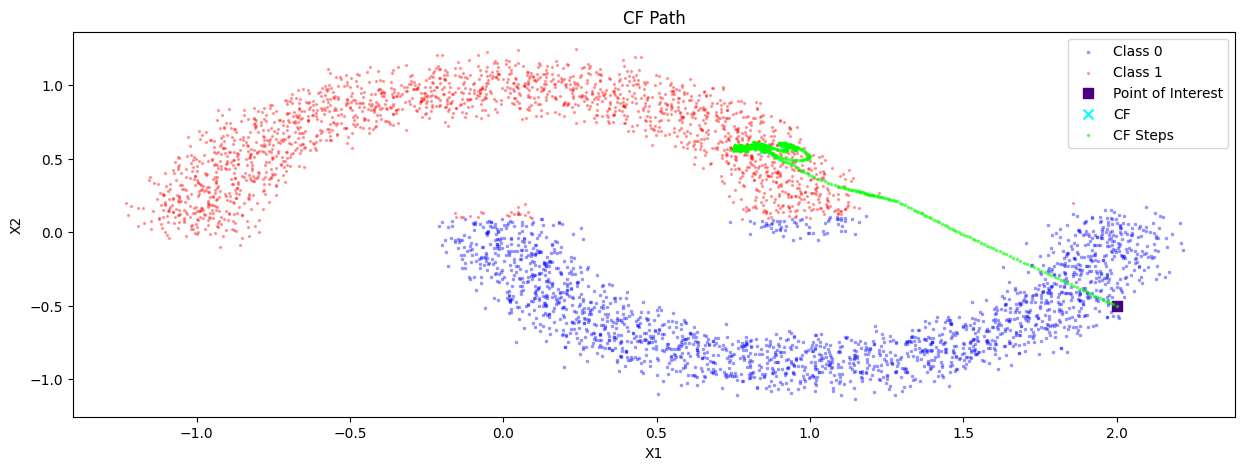

In [89]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, data, y_pred_ensemble_points)

In [90]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    # Choose as reference point the point with highest probability for this class in the dataset
    with torch.no_grad():
        probs_reference = ensemble_probs(torch.tensor(data)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(data[idx_reference])
    print(reference_point)
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = epistemic_uncertainty_ensemble(probs_ensemble)




        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point, num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        eu_line = epistemic_uncertainty_ensemble(probs_ensemble_line_points)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam1 = 0.7
        lam2 = 1 if target_probs > 0.5 else 0
        loss = (-target_probs) +  lam1*(eu_line.mean()) + lam2*(au_line.std())
        #loss = (-target_probs).add(t*au)
        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au_line.std() , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected_au, cf_steps_connected_au = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=.5, n_points=10)

tensor([1.1142, 0.0089])


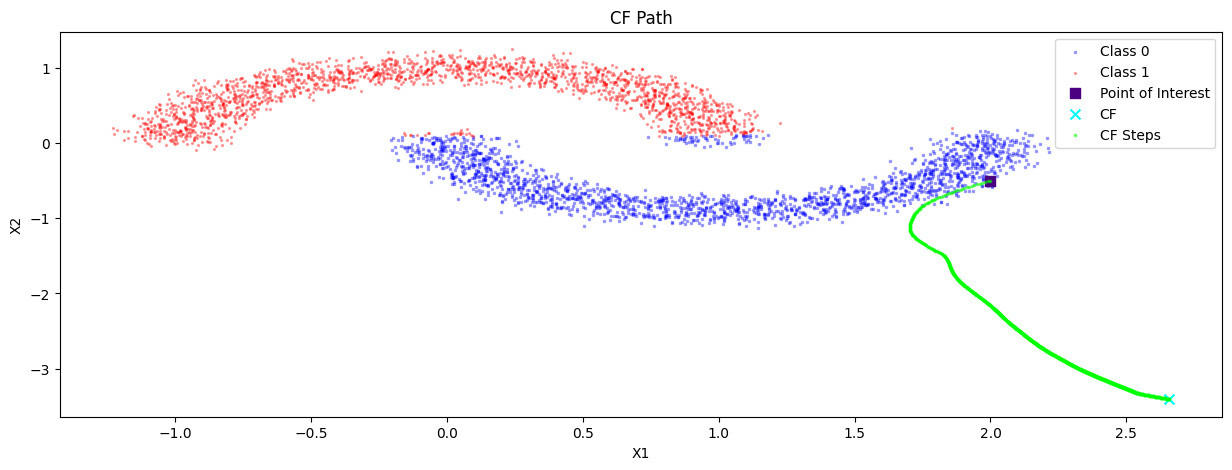

In [91]:
visualize_cf_and_steps(cf_connected_au,cf_steps_connected_au, data, y_pred_ensemble_points)

## Similarity

In [92]:
def similiarity_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        tu_point = total_uncertainty_ensemble(probs_ensemble)
        au_point = aleatoric_uncertainty_ensemble(probs_ensemble)

        reference_point = point_to_explain.clone().detach().requires_grad_(True)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam = .7
        loss = (1-lam)*-target_probs - lam*torch.std(au_line)
        #loss = -(1-lam)*target_probs  + lam*tu_point

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_similiar, cf_steps_similiar = similiarity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

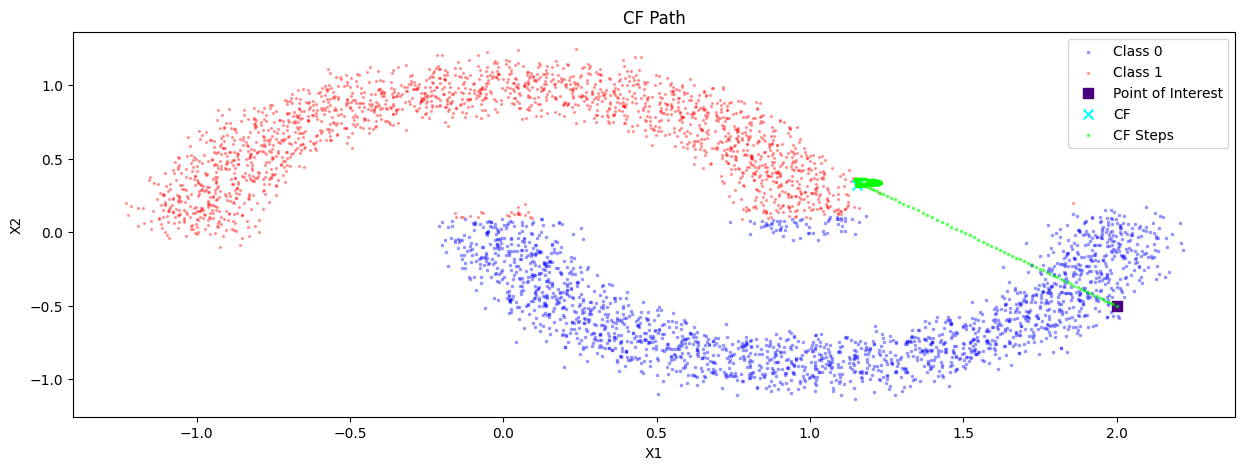

In [93]:
visualize_cf_and_steps(cf_similiar,cf_steps_similiar, data, y_pred_ensemble_points)

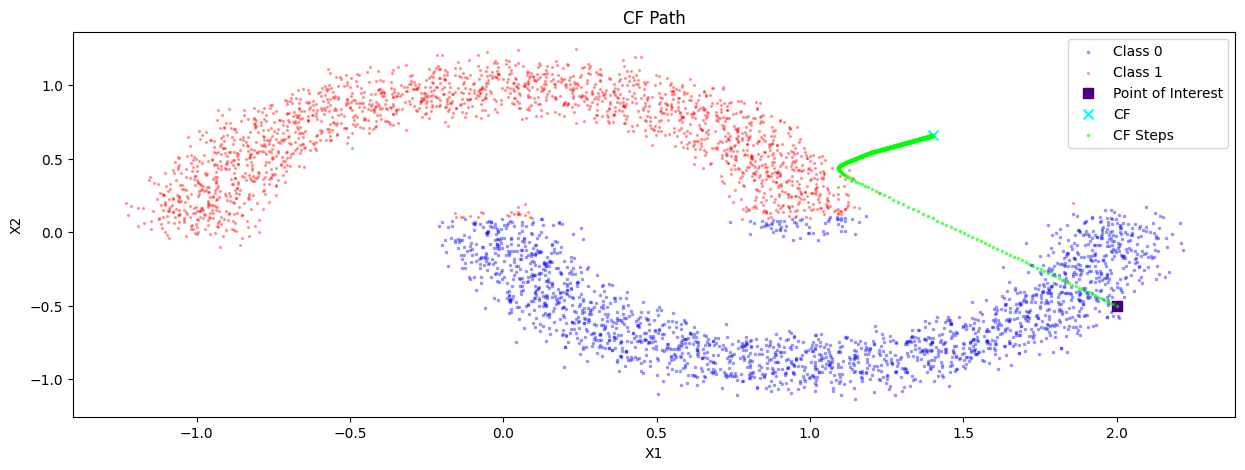

In [94]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, data, y_pred_ensemble_points)

In [95]:
cf_similiar, cf_valid
print(point_of_interest)
torch.linalg.norm(cf_similiar - point_of_interest, ord=2),torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor([[ 2.0000, -0.5000]], requires_grad=True)


(tensor(1.1765, grad_fn=<AmaxBackward0>),
 tensor(1.3029, grad_fn=<AmaxBackward0>))

## Sparsisity

In [96]:
def sparse_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        #loss = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward()

        # Update the gradients of delta_ball
        gradients = counter_factual.grad.requires_grad_(True)
        base_gradients = torch.eye(gradients.shape[-1])
        gradients_normalized = torch.nn.functional.normalize(gradients, dim=-1)

        similarity_matrix = torch.matmul(gradients_normalized, base_gradients.T).mean()

        loss2 = -similarity_matrix
        loss2.backward()

        lam = 0.5
        counter_factual.grad = (lam*counter_factual.grad + (1-lam)*gradients.grad).mean(dim=0,keepdim=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_delta_ball_epsilon(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        loss2 = -(target_probs_delta_ball.mean())
        #loss = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward(retain_graph=True)
        loss2.backward(retain_graph=True)

        epsilon = delta_ball.grad.abs().mean() - delta_ball.grad.abs().std()
        bernoulli_prob_sampled =  1 - (abs(delta_ball.grad) <= epsilon).float().mean(dim=0)
        bernoulli_prob_importance = (delta_ball.grad.abs() / delta_ball.grad.abs().sum(dim=1).view(-1,1)).mean(dim=0) # States the proportion each dimension does to the total change



        bernoulli_variable = torch.bernoulli(bernoulli_prob_importance)

        counter_factual.grad = bernoulli_variable * counter_factual.grad
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_iteratively(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    bernoulli_prob_importance = torch.zeros(counter_factual.shape)
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs
        loss2 = -(target_probs_delta_ball.mean())

        # Backpropagate
        loss.backward(retain_graph=True)
        loss2.backward(retain_graph=True)
        most_magnitude_feature_change = delta_ball.grad.abs().mean(dim=0).argmax()
        bernoulli_prob_importance[0,most_magnitude_feature_change] += 1

        bernoulli_variable = torch.bernoulli(bernoulli_prob_importance.div(bernoulli_prob_importance.sum()))

        counter_factual.grad = bernoulli_variable * counter_factual.grad
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

def sparse_procedure_baseline(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]


    # sample_ball
    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    # Optimization Iteratio

    t = 0
    T = 0
    bernoulli_prob_importance = torch.zeros(counter_factual.shape)
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = total_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        tu_delta_ball = total_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        # Calculate the loss
        loss =  -target_probs + 0.01*torch.linalg.norm(counter_factual - point_of_interest, ord=1)

        # Backpropagate
        loss.backward(retain_graph=True)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1

    return counter_factual.detach(), counter_factual_steps

cf_sparse, cf_sparse_steps = sparse_procedure_iteratively(point_of_interest, desired_validity=DESIRED_VALIDITY, delta=0.2)
cf_sparse2, cf_sparse_steps2 = sparse_procedure_baseline(point_of_interest, desired_validity=DESIRED_VALIDITY, delta=0.2)

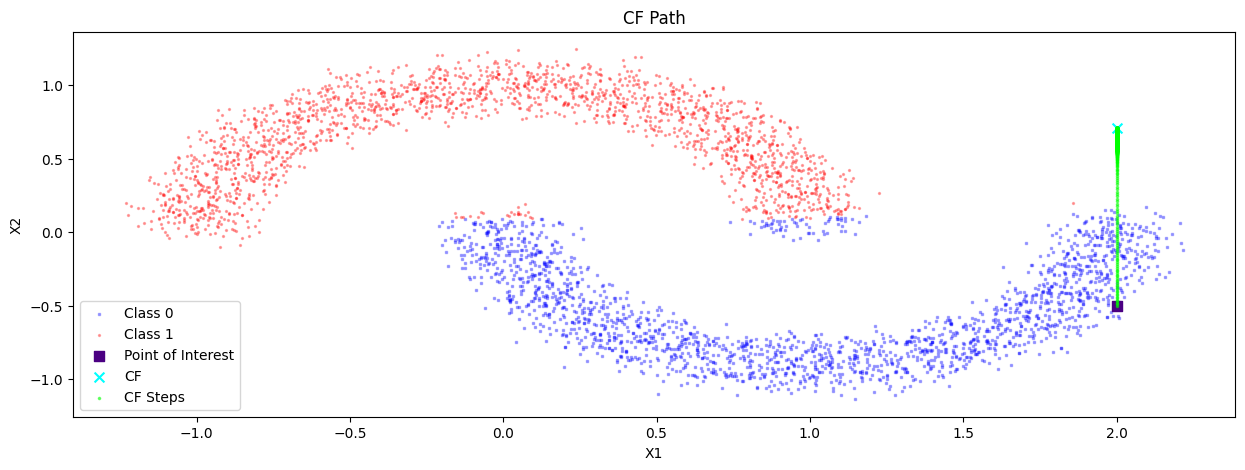

In [97]:
visualize_cf_and_steps(cf_sparse, cf_sparse_steps, data, y_pred_ensemble_points)

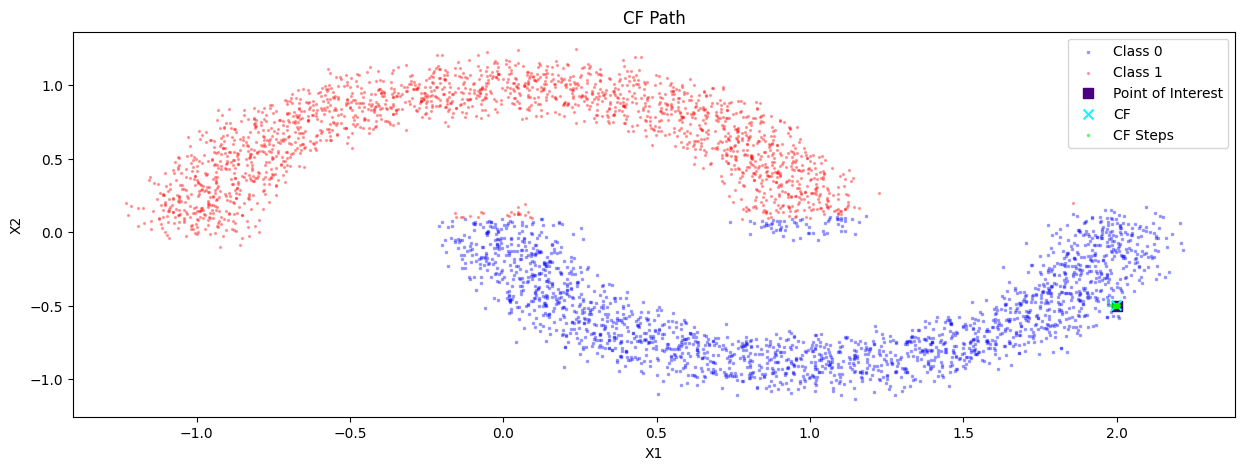

In [98]:
visualize_cf_and_steps(cf_sparse2, cf_sparse_steps2, data, y_pred_ensemble_points)

In [99]:
# Check how sparse the point is in contrast to validity
diff_valids = []
diff_sparse = []
diff_sparse2 = []
cf_valid, _ = validity_procedure(point_of_interest, desired_validity=0.9)
for _ in range(10):
    cf_sparse,_ = sparse_procedure_iteratively(point_of_interest,desired_validity=0.9, delta=0.2)
    cf_sparse2,_ = sparse_procedure_baseline(point_of_interest, desired_validity=0.9)
    diff_v = torch.norm(cf_valid - point_of_interest, p=1).item()
    diff_s = torch.norm(cf_sparse - point_of_interest, p=1).item()
    diff_s2 = torch.norm(cf_sparse2 - point_of_interest, p=1).item()
    diff_valids.append(diff_v)
    diff_sparse.append(diff_s)
    diff_sparse2.append(diff_s2)
print(f"Valid Diff: {np.mean(diff_valids)} +/- {np.std(diff_valids)}")
print(f"Sparse Diff: {np.mean(diff_sparse)} +/- {np.std(diff_sparse)}")
print(f"Sparse Diff: {np.mean(diff_sparse2)} +/- {np.std(diff_sparse2)}")

Valid Diff: 1.7559415102005005 +/- 0.0
Sparse Diff: 1.2091341018676758 +/- 0.0
Sparse Diff: 0.004914224147796631 +/- 0.0


## Feasability

In [100]:
from sklearn.neighbors import NearestNeighbors


def get_knn_points(point,k=5):
    knn = NearestNeighbors(n_neighbors=k,algorithm="brute")
    knn.fit(data)
    distances, indices = knn.kneighbors(point.detach().numpy())
    return torch.tensor(data[indices]).requires_grad_(True)

def probability_point_given_data(point):
    knn_points = get_knn_points(point, k=5)
    max_distance = torch.linalg.norm(knn_points - point, ord=2,dim=1).max()
#    return 1/(1+torch.exp(max_distance))
    return 1/torch.exp(max_distance)

probability_point_given_data(point_of_interest.detach())

tensor(0.9484, grad_fn=<MulBackward0>)

In [101]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        sampled_line_points = sample_line(counter_factual, counter_factual_steps[0], num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_line_points = probs_ensemble_line_points.mean(dim=0)
        eu_line = epistemic_uncertainty_ensemble(probs_ensemble_line_points)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)
        tu_line = total_uncertainty_ensemble(probs_ensemble_line_points)

        target_probs = probs[0,desired_class]
        target_probs_line = probs_line_points[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        lam = .6
        loss = (1-lam)* (-target_probs) + lam*(eu_line.max())
        #loss = (-target_probs_line).mean()

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable_eu, cf_steps_feasable_eu = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,n_points=10)

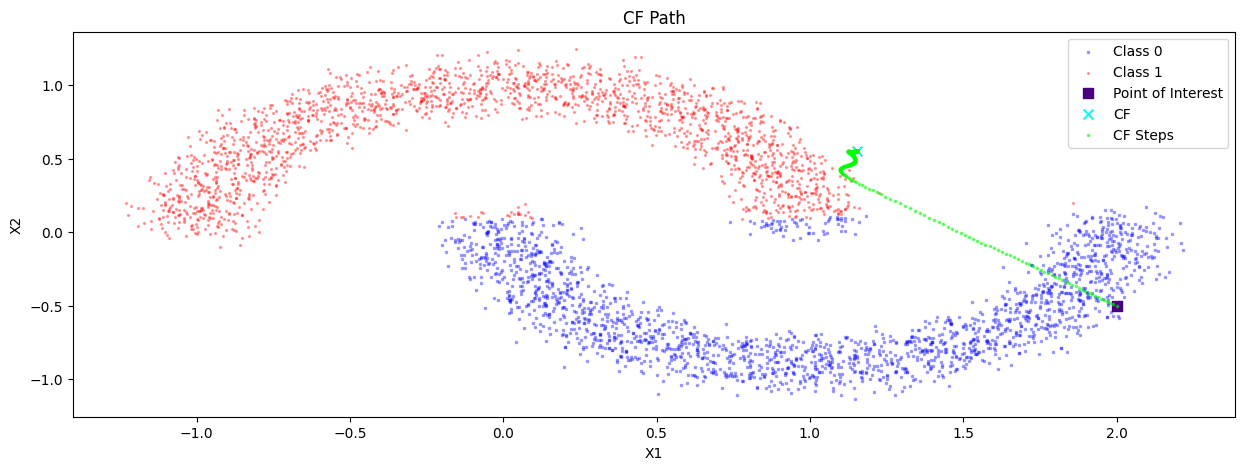

In [102]:
visualize_cf_and_steps(cf_feasable_eu, cf_steps_feasable_eu, data, y_pred_ensemble_points)

torch.Size([10000, 10, 2])
tensor(8.9778e-07, grad_fn=<MinBackward1>) tensor(1., grad_fn=<MaxBackward1>)


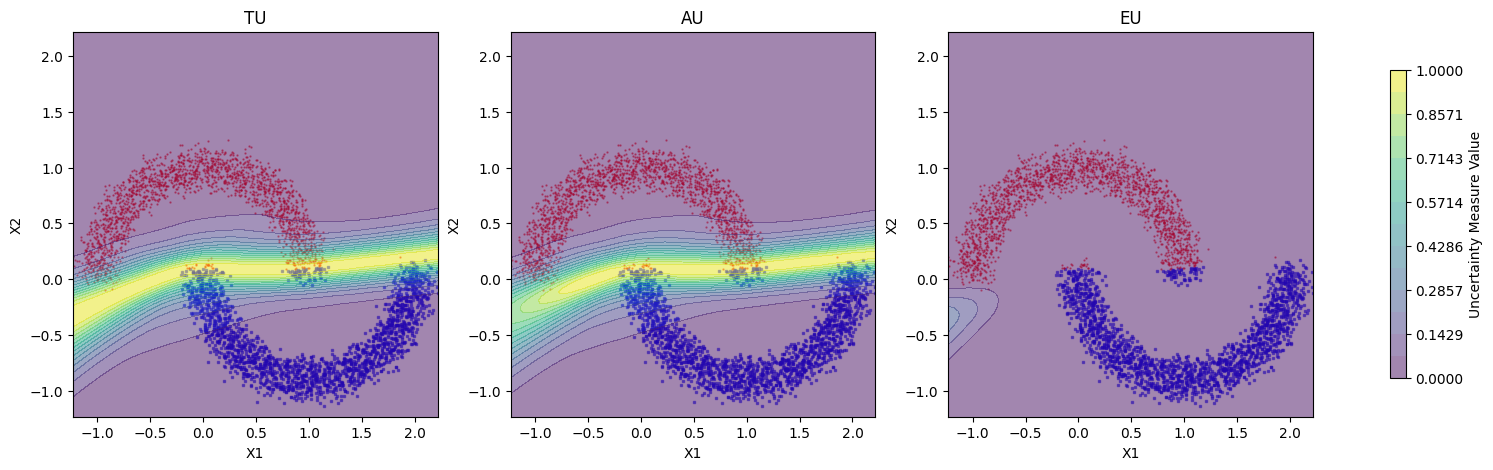

In [103]:
visualize_au_eu_tu_points(data,y_pred_ensemble_points)

In [104]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    au_delta_ball_start = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    eu_delta_ball_start = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # total uncertainty of the point itself


        # # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)

        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss#

        #loss = -target_probs + t*tu_point
        lam2 = 1 if target_probs > 0.5 else 0
        lam = 0.7
        loss = (-target_probs_delta_ball.mean()) + lam*( eu_delta_ball.max()) #- lam2*(au_delta_ball.max())
        #loss = (1-lam)*(-target_probs_delta_ball.mean()) + lam*tu_delta_ball.std()

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0).view(-1,2)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=.5,n_points=10)

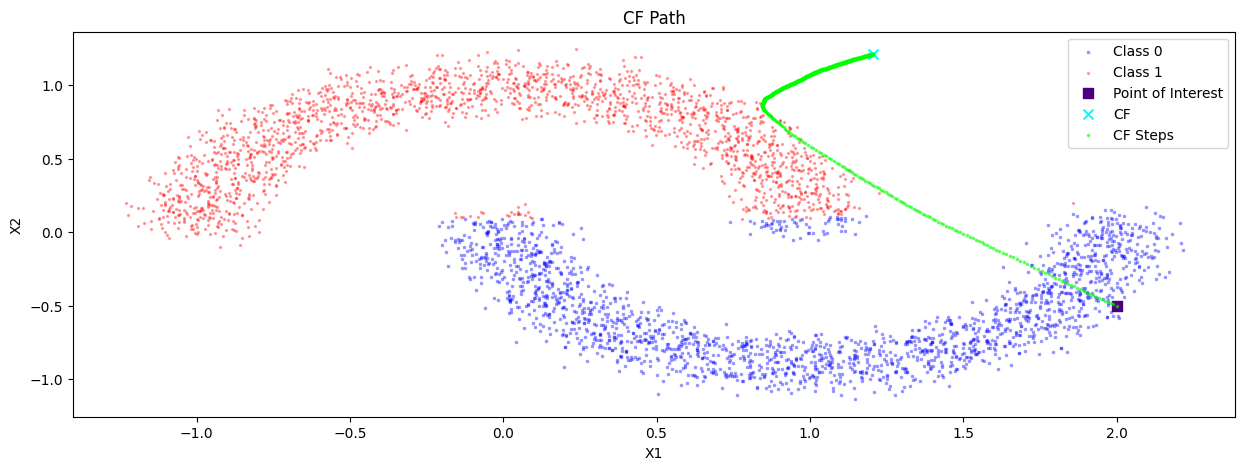

In [105]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, data, y_pred_ensemble_points)

In [106]:
def feasability_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
    #delta_ball = get_knn_points(point_to_explain, k=n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball)
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    tu_delta_ball_start = total_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    au_delta_ball_start = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    eu_delta_ball_start = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).detach()
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)

        # total uncertainty of the point itself


        # # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points)
        #delta_ball = get_knn_points(counter_factual, k=n_points)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)

        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss#

        #loss = -target_probs + t*tu_point
        lam2 = 1 if target_probs > 0.5 else 0
        lam = 0.7
        loss = (-target_probs_delta_ball.mean()) + lam*( eu_delta_ball.std()) #- lam2*(au_delta_ball.max())
        #loss = (1-lam)*(-target_probs_delta_ball.mean()) + lam*tu_delta_ball.std()

        # Backpropagate
        loss.backward()
        counter_factual.grad = delta_ball.grad.mean(dim=0).view(-1,2)
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_feasable, cf_steps_feasable = feasability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY,delta=.5,n_points=10)

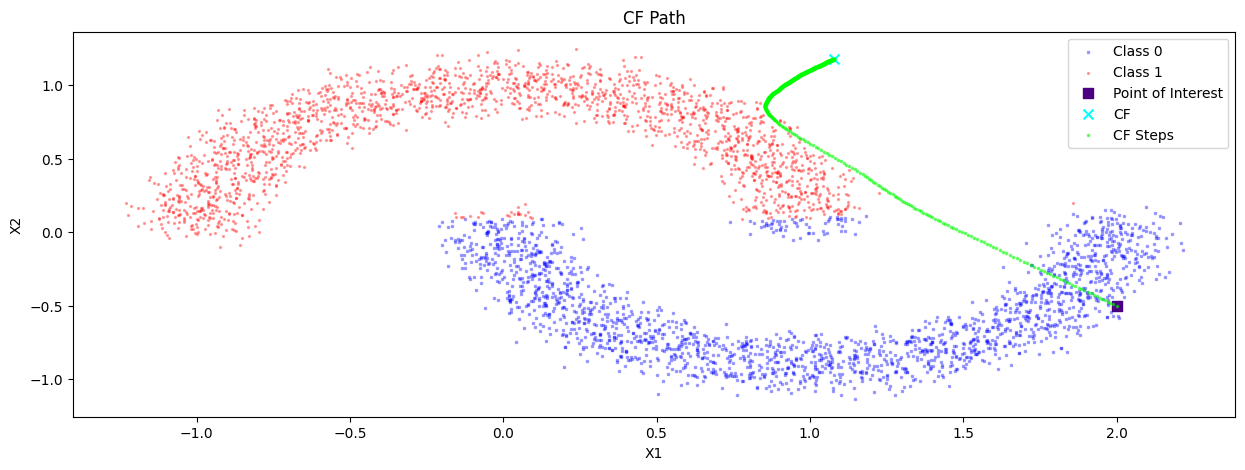

In [107]:
visualize_cf_and_steps(cf_feasable, cf_steps_feasable, data, y_pred_ensemble_points)